# Model Trainig And Evaluation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
data = pd.read_csv("/content/drive/MyDrive/Churn Prediction System /Telco-Customer-Churn.csv")
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
data.shape

(7043, 21)

In [ ]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")


In [ ]:
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
data["TotalCharges"].fillna(data["TotalCharges"].median())

,TotalCharges
0,29.85
1,1889.50
2,108.15
3,1840.75
4,151.65
...,...
7038,1990.50
7039,7362.90
7040,346.45
7041,306.60


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
data.isnull().sum()

,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0
OnlineBackup,0


In [ ]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [ ]:
data["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


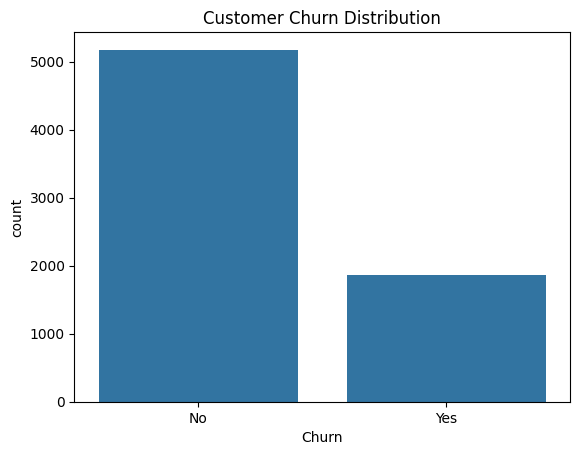

In [ ]:
sns.countplot(x="Churn" , data=data)
plt.title("Customer Churn Distribution")
plt.show()

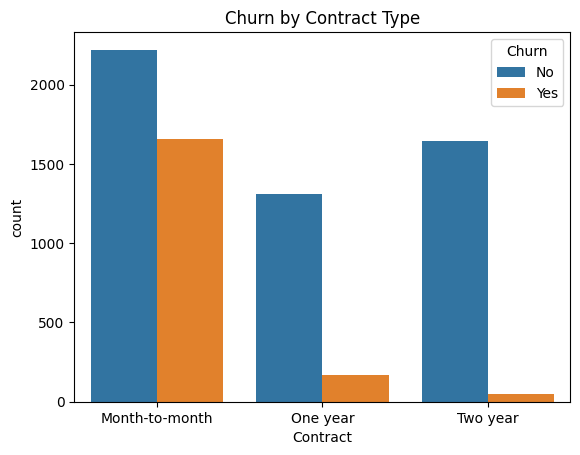

In [ ]:
sns.countplot(x="Contract", hue="Churn", data=data)
plt.title("Churn by Contract Type")
plt.show()

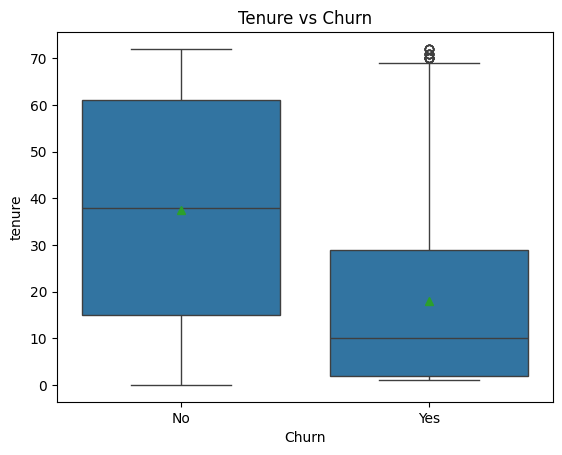

In [ ]:
sns.boxplot(x="Churn",
            y="tenure",
            showmeans=True,
            data=data)
plt.title("Tenure vs Churn")
plt.show()

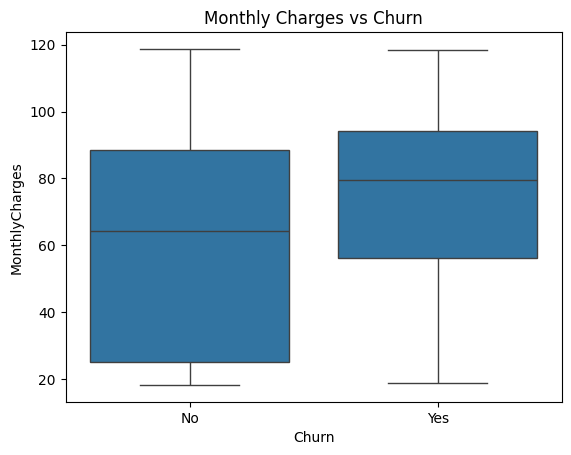

In [ ]:
sns.boxplot(x="Churn", y="MonthlyCharges", data=data)
plt.title("Monthly Charges vs Churn")
plt.show()

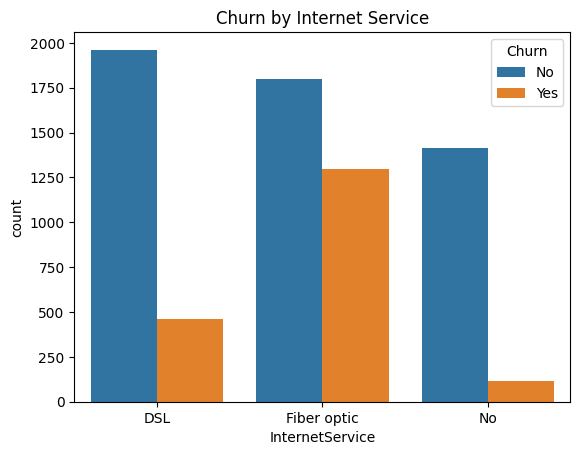

In [ ]:
sns.countplot(x="InternetService", hue="Churn", data=data)
plt.title("Churn by Internet Service")
plt.show()

In [ ]:
data_encoded = pd.get_dummies(data , drop_first=True)

In [ ]:
data_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [ ]:
data_encoded.shape

(7043, 31)

In [ ]:
X= data_encoded.drop("Churn_Yes" , axis=1)
y= data_encoded["Churn_Yes"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
#Model-1 : Logistic Regression
from sklearn.linear_model import LogisticRegression
model1 = LogisticRegression(max_iter=2000)
model1.fit(X_train_scaled, y_train)
model1_pred = model1.predict(X_test_scaled)



In [ ]:
#Model-2 : RandomForestClassifier
model2 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
)

model2.fit(X_train , y_train)
model2_pred=model2.predict(X_test)

In [ ]:
#Model-3: GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingClassifier
model3= GradientBoostingClassifier(
    n_estimators=200,
    random_state=42
)

model3.fit(X_train , y_train)
model3_pred = model3.predict(X_test)

In [ ]:
#model4  : Naive Bayes
from sklearn.naive_bayes import GaussianNB
model4 = GaussianNB()
model4.fit(X_train_scaled , y_train)
model4_pred = model4.predict(X_test_scaled)

In [ ]:
#Model 5 : SVM
from sklearn.svm import SVC
model5 = SVC()
model5.fit(X_train_scaled , y_train)
model5_pred = model5.predict(X_test_scaled)

In [ ]:
#Accuracy Score of evry model
print("Logistic Accuracy:", accuracy_score(y_test, model1_pred))
print("RandomForest Accuracy:", accuracy_score(y_test, model2_pred))
print("GradientBoosting Accuracy:", accuracy_score(y_test, model3_pred))
print("Naive Bayes Accuracy:", accuracy_score(y_test, model4_pred))
print("SVM Accuracy:", accuracy_score(y_test, model5_pred))

Logistic Accuracy: 0.8197303051809794
RandomForest Accuracy: 0.7934705464868701
GradientBoosting Accuracy: 0.8140525195173882
Naive Bayes Accuracy: 0.6657203690560681
SVM Accuracy: 0.8140525195173882


In [ ]:
#Classification report
from sklearn.metrics import classification_report

print(classification_report(y_test, model1_pred))
print(classification_report(y_test, model2_pred))
print(classification_report(y_test, model3_pred))
print(classification_report(y_test, model4_pred))
print(classification_report(y_test, model5_pred))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.68      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.81      0.82      0.82      1409

              precision    recall  f1-score   support

       False       0.82      0.91      0.87      1036
        True       0.66      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.74      0.69      0.70      1409
weighted avg       0.78      0.79      0.78      1409

              precision    recall  f1-score   support

       False       0.85      0.91      0.88      1036
        True       0.69      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.77      0.73      0.74      1409
weighted avg       0.81      0.81      0.81      1409

              preci

In [ ]:
#confusion matrix
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, model1_pred))
print(confusion_matrix(y_test, model2_pred))
print(confusion_matrix(y_test, model3_pred))
print(confusion_matrix(y_test, model4_pred))
print(confusion_matrix(y_test, model5_pred))


[[933 103]
 [151 222]]
[[946  90]
 [201 172]]
[[942  94]
 [168 205]]
[[605 431]
 [ 40 333]]
[[948  88]
 [174 199]]


In [ ]:
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": model1,
    "Random Forest": model2,
    "Gradient Boosting": model3,
    "SVM": model5
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(name, "CV Accuracy:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression CV Accuracy: 0.8033517283373122
Random Forest CV Accuracy: 0.791000125008065
Gradient Boosting CV Accuracy: 0.7999449561262016
SVM CV Accuracy: 0.7346301575908123


# Starting the Explainable AI Phase

In [ ]:
!pip install shap

In [ ]:
import shap

In [ ]:
X_test_scaled_df = pd.DataFrame(X_test_scaled , columns=X.columns)

In [ ]:
explainer = shap.LinearExplainer(model1 , X_train_scaled)


In [ ]:
shap_values = explainer.shap_values(X_test_scaled_df)

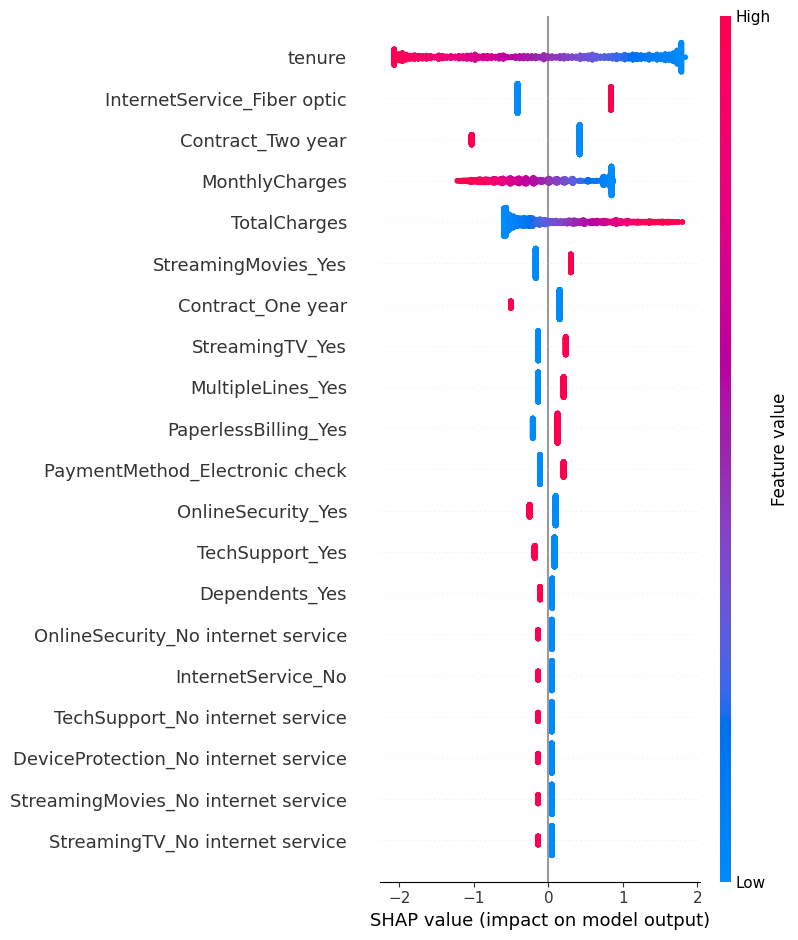

In [ ]:
shap.summary_plot(shap_values , X_test_scaled_df)

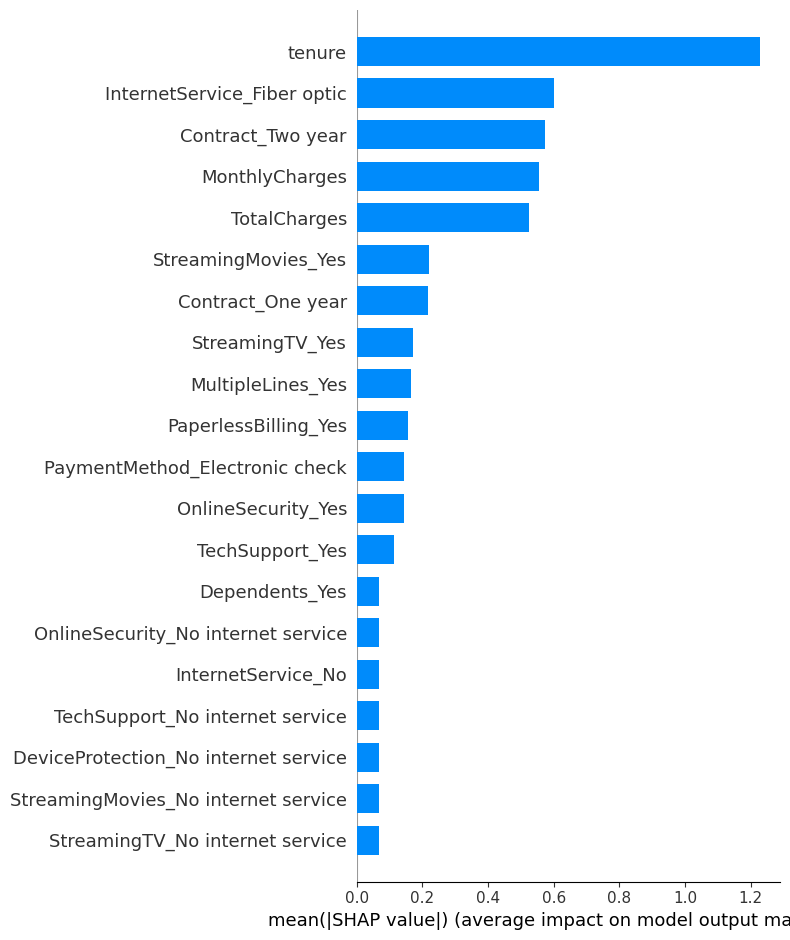

In [ ]:
shap.summary_plot(shap_values , X_test_scaled_df , plot_type="bar")

In [ ]:
#Retention Strategy System
def retention_strategy(customer):

    strategies = []

    if customer["tenure"] < 6:
        strategies.append("Provide onboarding support and welcome discount")

    if customer["MonthlyCharges"] > 80:
        strategies.append("Offer personalized discount or bundle plan")

    if customer["Contract_Two year"] == 0:
        strategies.append("Encourage upgrade to long-term contract")

    if customer["InternetService_Fiber optic"] == 1:
        strategies.append("Provide premium technical support")

    return strategies

In [ ]:
shap.initjs()

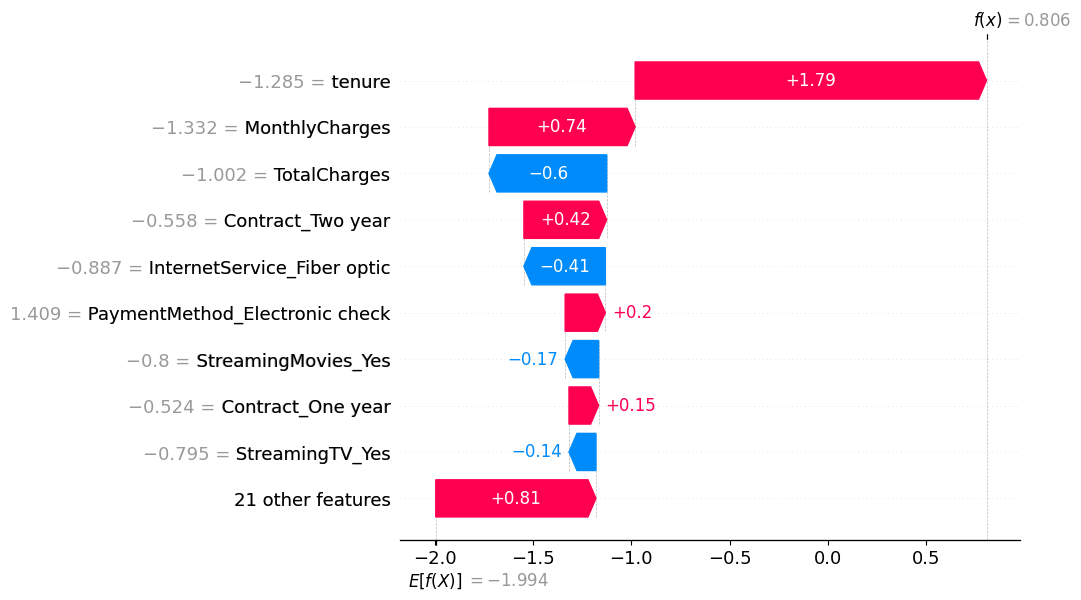

In [ ]:
shap.plots.waterfall(
    shap.Explanation(
      base_values=explainer.expected_value,
      values=shap_values[0],
      data=X_test_scaled_df.iloc[0],
      feature_names=X.columns
)
)

In [ ]:
model1.predict_proba(X_test_scaled_df.iloc[[0]].values)

array([[0.30883246, 0.69116754]])

In [ ]:
#Showing Churn Risk Levels
def churn_risk(probability):

    if probability < 0.30:
        return "Low Risk"

    elif probability < 0.60:
        return "Medium Risk"

    else:
        return "High Risk"

In [ ]:
proba = model1.predict_proba(X_test_scaled_df)

churn_prob = proba[:,1]

risk_levels = [churn_risk(p) for p in churn_prob]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:

def retention_action(customer, probability):

    actions = []

    if probability > 0.6:
        actions.append("Immediate retention offer")

    if customer["tenure"] < 6:
        actions.append("Onboarding support")

    if customer["MonthlyCharges"] > 80:
        actions.append("Discount or bundle plan")

    if customer["Contract_Two year"] == 0:
        actions.append("Promote long-term contract")

    return actions

In [ ]:
import joblib

joblib.dump(model1 , "churn_model.pkl")
joblib.dump(scaler , "scaler.pkl")


['scaler.pkl']

In [ ]:
import json
features = list(X.columns)

with open("feature_columns.json","w" ) as f:
  json.dump(features , f)